In [2]:
import torch 
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader


In [3]:
file_path = "chapter1_dataProcessing /the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    vardict_data = file.read()
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}

/home/dharmsingh/miniconda3/envs/ml/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
class GptDataset(Dataset):
    def __init__(self,txt,tokenizer,max_length, stride):
        super().__init__()
        self.input_ids = []
        self.target_ids =[]
        token_ids = tokenizer.encode(txt)
        
        for i in range(0,len(token_ids)-max_length , stride):
            input_chunk = token_ids[i:i+max_length]
            target_chunk = token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, index):
        return self.input_ids[index],self.target_ids[index]
    
def create_dataloader_v1(txt, batch_size=4, max_length=256,stride=128, shuffle=True, drop_last=True,num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GptDataset(txt,tokenizer,max_length,stride)
    dataloader = DataLoader(dataset,batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)
    
    return dataloader   
    

In [6]:
class DummyGPTModel(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.token_embed = nn.Embedding(config["vocab_size"], config["emb_dim"])
        self.pos_embed = nn.Embedding(config["context_length"] , config["emb_dim"])
        self.drop_emb = nn.Dropout(config["drop_rate"])
        self.trf_block = nn.Sequential(
            *[DummyTransformerBlock(config) for _ in range(config["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(config["emb_dim"])
        self.out_head = nn.Linear(config["emb_dim"] , config["vocab_size"],bias=False)
        
    def forward(self,in_idx):
        batch_size, seq_len = in_idx.shape
        token_embed =self.token_embed(in_idx)
        pos_embed =self.pos_embed(torch.arange(seq_len))
        
        x= token_embed+ pos_embed
        # print(f" shape of embedding : {x.shape}")
        
        x= self.drop_emb(x)
        x= self.trf_block(x)
        
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
        
        
        


class DummyTransformerBlock(nn.Module):
    def __init__(self ,cfg ):
        super().__init__()
        self.attention = MultiheadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = DummyLayerNorm(cfg["emb_dim"])
        self.norm2 = DummyLayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
        
    def forward(self, x):
        shortcut =x
        x= self.norm1(x)
        x= self.attention(x)
        x= self.drop_shortcut(x)
        x =x+shortcut
        
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        
        return x
    
        
        
        
        
        
    

class DummyLayerNorm(nn.Module):
    def __init__(self , emb_dim, eps = 1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
        
        
    def forward(self , x):
        mean = x.mean(dim =-1 , keepdim = True) 
        var = x.var(dim =-1 , keepdim = True ,unbiased= False) 
        norm_x =  (x-mean)/torch.sqrt(var + self.eps)
        
        
        return self.scale * norm_x + self.shift
    

class GELU(nn.Module) :
    def __init__(self):
        super().__init__()
    def forward(self,x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
            ))
        
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"] , 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear( 4 * cfg["emb_dim"] , cfg["emb_dim"])
        )
    
    def forward(self, x):
        return self.layers(x)


class MultiheadAttention(nn.Module):
    def __init__(self, d_in, d_out,context_length, dropout, num_heads, bias=False):
        super().__init__()
        self.num_heads = num_heads
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out = d_out,
        self.head_dim = d_out//num_heads
        
        self.d_in = d_in
        self.k_weights = nn.Linear(d_in,d_out , bias )
        self.q_weights = nn.Linear(d_in,d_out , bias )
        self.v_weights = nn.Linear(d_in,d_out , bias )
        self.proj = nn.Linear(d_out,d_out)
        
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('multi_mask' , torch.triu(torch.ones(context_length,context_length), diagonal=1))
        
    def forward(self,x):
        b, num_tokens, d_in = x.shape
        keys= self.k_weights(x)
        queries= self.q_weights(x)
        values= self.v_weights(x)
        
        
        
        keys = keys.view(b,num_tokens , self.num_heads, self.head_dim)
        queries = queries.view(b,num_tokens , self.num_heads, self.head_dim)
        values = values.view(b,num_tokens , self.num_heads, self.head_dim)
        
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        
        
        
        attention = queries @ keys.transpose(-1,-2)
        # return attention
        
        mask_bool = self.multi_mask.bool()[:num_tokens, :num_tokens]
        masked_attention = attention.masked_fill( mask_bool ,-torch.inf)
        atten_soft = torch.softmax(masked_attention/keys.shape[-1]**0.5 , dim=-1)
        # print(f"attention soft shape {atten_soft.shape , values.shape}")
        
        
        context_vec = (atten_soft @ values).transpose(1,2)
        
        context_vec = context_vec.contiguous().view(b,num_tokens,-1)
        context_vec = self.proj(context_vec)
        
        return context_vec
        
        
        
    
        

In [7]:
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch= torch.stack(batch).to(device)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [8]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

torch.Size([2, 4, 50257])
Total number of parameters: 162,419,712


In [68]:
print("Token embedding layer shape:", model.token_embed.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [110]:
def generate_text_simple(model, idx,max_new_tokens, context_size):
    # print(f'idx from simple :{idx}')
    for _ in range(max_new_tokens):
        idx_cond = idx[: , -context_size:]
        # print(f'idx_cond from simple :{idx_cond}')
        
        with torch.no_grad():
            logits = model(idx_cond).to(device)
            
        # print(f'logit before from simple :{logits.shape}')
        
        logits  = logits[: , -1 ,:]
        # print(f'logit afterfrom simple :{logits.shape}')
        
    
        probs = torch.softmax(logits , dim =-1)
        idx_next = torch.argmax(probs , dim=-1 , keepdim=True)
        idx = torch.cat((idx, idx_next), dim =1).to(device)
    
    return idx


In [79]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)


encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [80]:
model.eval()
out = generate_text_simple(model=model,idx=encoded_tensor , 
                        max_new_tokens=6,
                        context_size=GPT_CONFIG_124M["context_length"]
                        )
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 29739,   554]])
Output length: 10


In [81]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswick Exit In


In [43]:
def text_to_token_ids(text,tokenizer):
    encode = tokenizer.encode(text , allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encode).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids , tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


In [83]:
token_ids = generate_text_simple(
model=model,
idx=text_to_token_ids(start_context, tokenizer),
max_new_tokens=10,
context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Hello, I am Featureiman Byeswick Exit Ingraded�gall 38


In [92]:
torch.manual_seed(123)
len_verdict_data = len(vardict_data)
total_token = tokenizer.encode(vardict_data)
train_ratio = 0.90
split_idx = int(train_ratio * len(vardict_data))
train_data = vardict_data[:split_idx]
val_data = vardict_data[split_idx:]


In [94]:
train_loader = create_dataloader_v1(train_data,batch_size=2,max_length=GPT_CONFIG_124M["context_length"],
                                    stride=GPT_CONFIG_124M["context_length"],
                                    drop_last=True,
                                    shuffle=True,
                                    num_workers=0)

val_loader = create_dataloader_v1(val_data,batch_size=2,max_length=GPT_CONFIG_124M["context_length"],
                                    stride=GPT_CONFIG_124M["context_length"],
                                    drop_last=False,
                                    shuffle=False,
                                    num_workers=0)

In [96]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [97]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)

    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(

    logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [98]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:

        return float("nan")

    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
            input_batch, target_batch, model, device
            )

            total_loss += loss.item()

        else:

            break

    return total_loss / num_batches

In [99]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
    print("Training loss:", train_loss)
    
    print("Validation loss:", val_loss)

Training loss: 10.988526768154568
Validation loss: 10.991588592529297


In [102]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=eval_iter
        )
        model.train()
        return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
        model=model, idx=encoded,
        max_new_tokens=50, context_size=context_size
        )
        
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        
        print(decoded_text.replace("\n", " "))
        model.train()

In [103]:
def train_model_simple(model, train_loader, val_loader, 
                    optimizer, device, num_epochs,
                    eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):

        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()

            loss = calc_loss_batch(
            input_batch, target_batch, model, device)
            loss.backward()

            optimizer.step()

            tokens_seen += input_batch.numel()

            global_step += 1
            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(
                model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                f"Train loss {train_loss:.3f}, "
                f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(
        model, tokenizer, device, start_context
        )
        return train_losses, val_losses, track_tokens_seen

In [104]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(

model.parameters(),
lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
model, train_loader, val_loader, optimizer, device,
num_epochs=num_epochs, eval_freq=5, eval_iter=5,
start_context="Every effort moves you", tokenizer=tokenizer
)

KeyboardInterrupt: 

In [105]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
    epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)

    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()

In [45]:
def generate(model, idx, max_new_tokens, context_size,
temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:

            top_logits, _ = torch.topk(logits, top_k)

            min_val = top_logits[:, -1]
            logits = torch.where(
            logits < min_val,
            torch.tensor(float('-inf')).to(logits.device),
            logits
            )
        if temperature > 0.0:

            logits = logits / temperature

            probs = torch.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:

            break
        
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

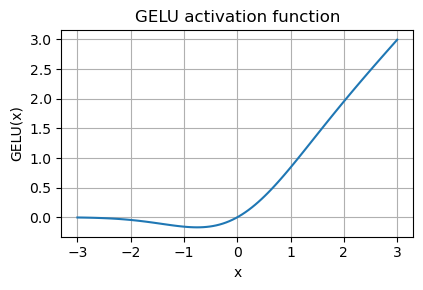

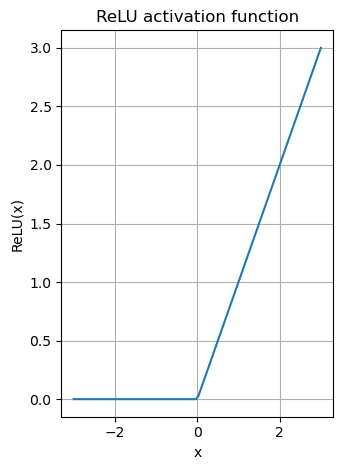

In [46]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [48]:
!pip install tensorflow>=2.15.0 tqdm>=4.66

ERROR: Operation cancelled by user
^C


In [10]:
import urllib.request
url = (
"https://raw.githubusercontent.com/rasbt/"
"LLMs-from-scratch/main/ch05/"
"01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7c3f2cbb0980>)

In [12]:
from gpt_download import download_and_load_gpt2 
settings, params = download_and_load_gpt2(
model_size="124M", models_dir="gpt2"
)


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 127kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:06<00:00, 149kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 117kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [07:22<00:00, 1.12MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 4.35MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:03<00:00, 138kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:03<00:00, 130kiB/s]  


In [13]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [14]:
model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [20]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [22]:
gpt = DummyGPTModel(NEW_CONFIG)
gpt.eval()

DummyGPTModel(
  (token_embed): Embedding(50257, 768)
  (pos_embed): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_block): Sequential(
    (0): DummyTransformerBlock(
      (attention): MultiheadAttention(
        (k_weights): Linear(in_features=768, out_features=768, bias=True)
        (q_weights): Linear(in_features=768, out_features=768, bias=True)
        (v_weights): Linear(in_features=768, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): DummyLayerNorm()
      (norm2): DummyLayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): DummyTransformerBlock(
      (attention): MultiheadAtte

In [24]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
        "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [49]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_embed.weight = assign(gpt.pos_embed.weight, params['wpe'])
    gpt.token_embed.weight = assign(gpt.token_embed.weight, params['wte'])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_block[b].attention.q_weights.weight = assign(
        gpt.trf_block[b].attention.q_weights.weight, q_w.T)
        gpt.trf_block[b].attention.k_weights.weight = assign(
        gpt.trf_block[b].attention.k_weights.weight, k_w.T)
        gpt.trf_block[b].attention.v_weights.weight = assign(
        gpt.trf_block[b].attention.v_weights.weight, v_w.T)
        q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_block[b].attention.q_weights.bias = assign(
        gpt.trf_block[b].attention.q_weights.bias, q_b)
        gpt.trf_block[b].attention.k_weights.bias = assign(
        gpt.trf_block[b].attention.k_weights.bias, k_b)
        gpt.trf_block[b].attention.v_weights.bias = assign(
        gpt.trf_block[b].attention.v_weights.bias, v_b)
        gpt.trf_block[b].attention.proj.weight = assign(
        gpt.trf_block[b].attention.proj.weight,
        params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_block[b].attention.proj.bias = assign(
        gpt.trf_block[b].attention.proj.bias,
        params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_block[b].ff.layers[0].weight = assign(
        gpt.trf_block[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_block[b].ff.layers[0].bias = assign(
        gpt.trf_block[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_block[b].ff.layers[2].weight = assign(
        gpt.trf_block[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_block[b].ff.layers[2].bias = assign(
        gpt.trf_block[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_block[b].norm1.scale = assign(
        gpt.trf_block[b].norm1.scale,
        params["blocks"][b]["ln_1"]["g"])
        gpt.trf_block[b].norm1.shift = assign(
        gpt.trf_block[b].norm1.shift,
        params["blocks"][b]["ln_1"]["b"])
        gpt.trf_block[b].norm2.scale = assign(
        gpt.trf_block[b].norm2.scale,
        params["blocks"][b]["ln_2"]["g"])
        gpt.trf_block[b].norm2.shift = assign(
        gpt.trf_block[b].norm2.shift,
        params["blocks"][b]["ln_2"]["b"])
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


In [50]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

DummyGPTModel(
  (token_embed): Embedding(50257, 768)
  (pos_embed): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_block): Sequential(
    (0): DummyTransformerBlock(
      (attention): MultiheadAttention(
        (k_weights): Linear(in_features=768, out_features=768, bias=True)
        (q_weights): Linear(in_features=768, out_features=768, bias=True)
        (v_weights): Linear(in_features=768, out_features=768, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): DummyLayerNorm()
      (norm2): DummyLayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): DummyTransformerBlock(
      (attention): MultiheadAtte

In [51]:
torch.manual_seed(123)
token_ids = generate(
model=gpt,
idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
max_new_tokens=25,
context_size=NEW_CONFIG["context_length"],
top_k=50,
temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


